# OncoBridge-MMCAT — Drug Response Fine-Tuning v2
## Research-Grade Training & Evaluation

### Architecture:
```
mRNA + CNV + Mut + Meth
        ↓
OncoBridgeMMCAT_v7 backbone (FROZEN encoders)
        ↓
1920-dim patient representation
        ↓
Concat with 128-dim Drug Embedding  ← KEY FIX
        ↓
2048-dim → Regression Head → LN_IC50
```

### Key fixes from v1:
1. Drug embedding added — model now knows WHICH drug it predicts
2. DataParallel for T4×2 GPU utilization
3. Pre-stacked numpy arrays for fast DataLoader
4. Gradient accumulation (effective batch = 256)
5. More epochs with proper early stopping
6. Benchmark comparison cell

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 1 — IMPORTS, SETUP & CONFIG
# ═══════════════════════════════════════════════════════════════════════════

import os, gc, json, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score, mean_squared_error

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

def section(title):
    print('\n' + '═'*70)
    print(f'  {title}')
    print('═'*70)

# ── Device & Multi-GPU ────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count()
print(f'Device: {DEVICE} | GPUs: {N_GPUS}')
for i in range(N_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} | '
          f'{torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

# ── PATHS — update these ──────────────────────────────────────────────────
DATA_BASE = '/kaggle/input/datasets/proutkarshtiwari/drug-min-sample-100-tes-size-0-20'   # preprocessed parquets
CKPT_PATH = '/kaggle/input/models/proutkarshtiwari/oncobridgev7-95-74acc/pytorch/default/1/oncobridge_v7_best.pt'
OUT_DIR   = '/kaggle/working/'

PATH_MRNA   = f'{DATA_BASE}/ccle_mrna_scaled.parquet'
PATH_CNV    = f'{DATA_BASE}/ccle_cnv_scaled.parquet'
PATH_MUT    = f'{DATA_BASE}/ccle_mut_scaled.parquet'
PATH_METH   = f'{DATA_BASE}/ccle_meth_scaled.parquet'
PATH_IC50   = f'{DATA_BASE}/ccle_ic50_labels.parquet'
PATH_SPLITS = f'{DATA_BASE}/ccle_splits.json'

# ── CONFIG ────────────────────────────────────────────────────────────────
CONFIG = {
    # ── Gene counts — MUST match tcga_selected_genes.json ─────────────────
    'num_mrna_genes' : 8011,
    'num_cnv_genes'  : 3500,
    'num_mut_genes'  : 2500,
    'num_meth_genes' : 6000,

    # ── Architecture — IDENTICAL to TCGA training (do NOT change) ─────────
    'embed_dim'         : 384,
    'num_heads'         : 8,
    'num_encoder_layers': 6,
    'num_cross_layers'  : 4,
    'cnn_kernel'        : 16,
    'cnn_stride'        : 16,
    'ff_dim'            : 1536,
    'dropout'           : 0.20,
    'gate_init'         : 1.5,
    'use_grad_ckpt'     : False,
    'num_classes'       : 22,   # only needed to load TCGA checkpoint — replaced immediately

    # ── Drug embedding ─────────────────────────────────────────────────────
    # This is what tells the model WHICH drug it is predicting
    # Learned from scratch — starts random, learns drug identity
    'drug_embed_dim'    : 128,

    # ── Training ───────────────────────────────────────────────────────────
    'batch_size'        : 64,
    'grad_accum'        : 4,    # effective batch = 256 (same style as original)
    'num_workers'       : 4,
    'use_amp'           : True,
    'clip_grad'         : 1.0,
    'warmup_frac'       : 0.15,

    # Stage 1: head + drug embedding only (backbone fully frozen)
    'stage1_epochs'     : 30,
    'stage1_lr'         : 1e-3,
    'stage1_wd'         : 1e-4,
    'stage1_patience'   : 8,

    # Stage 2: also unfreeze cross_layers + fusion (encoders stay frozen)
    'stage2_epochs'     : 40,
    'stage2_lr_head'    : 1e-4,
    'stage2_lr_cross'   : 1e-5,
    'stage2_wd'         : 1e-4,
    'stage2_patience'   : 10,

    'checkpoint_ft'     : 'oncobridge_drug_response_best.pt',
}

print(f'\nConfig loaded.')
print(f'Effective batch size: {CONFIG["batch_size"]} × {CONFIG["grad_accum"]} = {CONFIG["batch_size"]*CONFIG["grad_accum"]}')
print(f'Stage 1: {CONFIG["stage1_epochs"]} epochs | Stage 2: {CONFIG["stage2_epochs"]} epochs')
print(f'Drug embedding dim: {CONFIG["drug_embed_dim"]}')

Device: cuda | GPUs: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB

Config loaded.
Effective batch size: 64 × 4 = 256
Stage 1: 30 epochs | Stage 2: 40 epochs
Drug embedding dim: 128


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 2 — LOAD PROCESSED CCLE DATA
#  Pre-stack all omics into contiguous numpy arrays for fast DataLoader
#  (dict-based lookup was the bottleneck causing 10min/epoch)
# ═══════════════════════════════════════════════════════════════════════════
section('2. LOAD PROCESSED CCLE DATA')

print('Loading omics parquets...')
t0 = time.time()
mrna_df = pd.read_parquet(PATH_MRNA)
cnv_df  = pd.read_parquet(PATH_CNV)
mut_df  = pd.read_parquet(PATH_MUT)
meth_df = pd.read_parquet(PATH_METH)
ic50_df = pd.read_parquet(PATH_IC50)
print(f'Loaded in {time.time()-t0:.1f}s')

print(f'  mRNA:     {mrna_df.shape}')
print(f'  CNV:      {cnv_df.shape}')
print(f'  Mutation: {mut_df.shape}')
print(f'  Meth:     {meth_df.shape}')
print(f'  IC50:     {ic50_df.shape}')

# ── Load splits ──────────────────────────────────────────────────────────
with open(PATH_SPLITS) as f:
    splits = json.load(f)
cl_train = splits['train']
cl_val   = splits['val']
cl_test  = splits['test']
print(f'\nCell line splits: Train={len(cl_train)} | Val={len(cl_val)} | Test={len(cl_test)}')

# ── Drug encoder ─────────────────────────────────────────────────────────
all_drugs  = sorted(ic50_df['DRUG_NAME'].unique())
drug_to_id = {d: i for i, d in enumerate(all_drugs)}
id_to_drug = {i: d for d, i in drug_to_id.items()}
n_drugs    = len(all_drugs)
print(f'Total drugs: {n_drugs}')

# ── Pre-stack omics into a single cell-line-indexed array ─────────────────
# KEY SPEED FIX: instead of dict lookup per sample, build one big matrix
# indexed by integer position. DataLoader then just does fast array indexing.
all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx      = {cl: i for i, cl in enumerate(all_cell_lines)}

print('\nPre-stacking omics arrays...')
t0 = time.time()
mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)  # (N_cl, 8011)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)   # (N_cl, 3500)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)   # (N_cl, 2500)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)  # (N_cl, 6000)
print(f'Pre-stacked in {time.time()-t0:.1f}s')
print(f'  Total omics RAM: {(mrna_arr.nbytes+cnv_arr.nbytes+mut_arr.nbytes+meth_arr.nbytes)/1e6:.0f} MB')

# Add integer cell-line index and drug_id to IC50 dataframe
ic50_df['cl_idx']   = ic50_df['ModelID'].map(cl_to_idx)
ic50_df['drug_idx'] = ic50_df['DRUG_NAME'].map(drug_to_id)
ic50_df = ic50_df.dropna(subset=['cl_idx']).copy()
ic50_df['cl_idx'] = ic50_df['cl_idx'].astype(int)

print(f'\nIC50 rows after indexing: {len(ic50_df):,}')
print(f'Unique drugs: {ic50_df["DRUG_NAME"].nunique()}')

del mrna_df, cnv_df, mut_df, meth_df
gc.collect()
print('Original dataframes deleted — RAM freed.')


══════════════════════════════════════════════════════════════════════
  2. LOAD PROCESSED CCLE DATA
══════════════════════════════════════════════════════════════════════
Loading omics parquets...
Loaded in 1.7s
  mRNA:     (507, 8011)
  CNV:      (507, 3500)
  Mutation: (507, 2500)
  Meth:     (507, 6000)
  IC50:     (45300, 13)

Cell line splits: Train=354 | Val=51 | Test=102
Total drugs: 215

Pre-stacking omics arrays...
Pre-stacked in 0.0s
  Total omics RAM: 41 MB

IC50 rows after indexing: 45,300
Unique drugs: 215
Original dataframes deleted — RAM freed.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 3 — DATASET & DATALOADER
#  Uses pre-stacked numpy arrays for O(1) fast lookup
# ═══════════════════════════════════════════════════════════════════════════
section('3. DATASET & DATALOADER')

class DrugResponseDataset(Dataset):
    """
    Each sample = one cell line × one drug → LN_IC50

    Fast design: omics stored as pre-stacked (N_cells, G) arrays.
    __getitem__ does a single integer index — no dict lookup.

    Returns:
        mrna:    (8011,)  float32
        cnv:     (3500,)  float32
        mut:     (2500,)  float32
        meth:    (6000,)  float32
        ic50:    scalar   float32  — regression label
        drug_id: scalar   int64    — which drug (for embedding + per-drug eval)
    """
    def __init__(self, ic50_df, cell_lines,
                 mrna_arr, cnv_arr, mut_arr, meth_arr):
        cl_set = set(cell_lines)
        sub    = ic50_df[ic50_df['ModelID'].isin(cl_set)].reset_index(drop=True)

        # Pre-extract as numpy for zero-copy tensor creation
        self.cl_idx   = sub['cl_idx'].values.astype(np.int32)
        self.drug_idx = sub['drug_idx'].values.astype(np.int64)
        self.ic50     = sub['LN_IC50'].values.astype(np.float32)

        # Shared references — no copy, just pointer to the big arrays
        self.mrna_arr = mrna_arr
        self.cnv_arr  = cnv_arr
        self.mut_arr  = mut_arr
        self.meth_arr = meth_arr

    def __len__(self):
        return len(self.ic50)

    def __getitem__(self, idx):
        ci = self.cl_idx[idx]
        return (
            torch.from_numpy(self.mrna_arr[ci]),   # (8011,)
            torch.from_numpy(self.cnv_arr[ci]),    # (3500,)
            torch.from_numpy(self.mut_arr[ci]),    # (2500,)
            torch.from_numpy(self.meth_arr[ci]),   # (6000,)
            torch.tensor(self.ic50[idx]),           # scalar
            torch.tensor(self.drug_idx[idx]),       # scalar int
        )


train_ds = DrugResponseDataset(ic50_df, cl_train, mrna_arr, cnv_arr, mut_arr, meth_arr)
val_ds   = DrugResponseDataset(ic50_df, cl_val,   mrna_arr, cnv_arr, mut_arr, meth_arr)
test_ds  = DrugResponseDataset(ic50_df, cl_test,  mrna_arr, cnv_arr, mut_arr, meth_arr)

print(f'Dataset sizes:')
print(f'  Train: {len(train_ds):,} samples')
print(f'  Val:   {len(val_ds):,} samples')
print(f'  Test:  {len(test_ds):,} samples')

nw = CONFIG['num_workers']
train_loader = DataLoader(
    train_ds, batch_size=CONFIG['batch_size'],
    shuffle=True, num_workers=nw,
    pin_memory=True, persistent_workers=(nw > 0),
    prefetch_factor=2 if nw > 0 else None,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=CONFIG['batch_size'] * 2,
    shuffle=False, num_workers=nw,
    pin_memory=True, persistent_workers=(nw > 0),
    prefetch_factor=2 if nw > 0 else None,
)
test_loader = DataLoader(
    test_ds, batch_size=CONFIG['batch_size'] * 2,
    shuffle=False, num_workers=nw,
    pin_memory=True, persistent_workers=(nw > 0),
    prefetch_factor=2 if nw > 0 else None,
)

print(f'\nDataLoaders built.')
print(f'  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

# Sanity check
t0 = time.time()
mrna_b, cnv_b, mut_b, meth_b, ic50_b, drug_b = next(iter(train_loader))
print(f'  First batch loaded in {time.time()-t0:.2f}s  ← should be <1s now')
print(f'  mRNA: {mrna_b.shape} | IC50 range [{ic50_b.min():.2f}, {ic50_b.max():.2f}]')
print(f'  Drug IDs in batch: {drug_b.unique().numel()} unique drugs')


══════════════════════════════════════════════════════════════════════
  3. DATASET & DATALOADER
══════════════════════════════════════════════════════════════════════
Dataset sizes:
  Train: 31,717 samples
  Val:   4,433 samples
  Test:  9,150 samples

DataLoaders built.
  Train batches: 495 | Val batches: 35
  First batch loaded in 0.51s  ← should be <1s now
  mRNA: torch.Size([64, 8011]) | IC50 range [-9.26, 11.76]
  Drug IDs in batch: 52 unique drugs


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 4 — MODEL ARCHITECTURE
#  Exact same classes as TCGA training — required for checkpoint loading
# ═══════════════════════════════════════════════════════════════════════════
section('4. MODEL ARCHITECTURE')

# ── All classes identical to TCGA training notebook ───────────────────────

class GeneImportanceLayer(nn.Module):
    """
    Per-gene learnable sigmoid gate. T-GEM inspired.
    init_val=1.5 → sigmoid(1.5)=0.818 (mostly open at start).
    Network learns to close gate on noisy/irrelevant genes.
    """
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))

    def forward(self, x):
        return x * torch.sigmoid(self.logits)


class ModalityEncoder(nn.Module):
    """
    Single-modality encoder: GeneGate → Linear → CNN → CLS + TransformerEncoder
    """
    def __init__(self, num_genes, embed_dim, num_heads, num_layers,
                 cnn_kernel, cnn_stride, ff_dim, dropout,
                 gate_init=1.5, use_ckpt=False):
        super().__init__()
        self.use_ckpt   = use_ckpt
        self.gene_gate  = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.input_proj = nn.Linear(1, embed_dim)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, embed_dim,
                      kernel_size=cnn_kernel, stride=cnn_stride,
                      padding=cnn_kernel // 2),
            nn.GELU(),
            nn.BatchNorm1d(embed_dim),
        )
        self.cls_token  = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        compressed      = (num_genes + cnn_kernel//2*2 - cnn_kernel) // cnn_stride + 1 + 1
        self.pos_emb    = nn.Parameter(torch.randn(1, compressed, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(embed_dim)

    def _tfm(self, x): return self.transformer(x)

    def forward(self, x):
        x = self.gene_gate(x)
        x = x.unsqueeze(-1)
        x = self.input_proj(x)
        x = x.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_emb[:, :x.size(1), :]
        if self.use_ckpt and self.training:
            x = grad_checkpoint(self._tfm, x, use_reentrant=False)
        else:
            x = self._tfm(x)
        return self.norm(x)


class CrossModalAttention4(nn.Module):
    """4-modality cross-modal attention."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        mods = ['mrna', 'cnv', 'mut', 'meth']
        self.cross_attns = nn.ModuleDict({
            m: nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
            for m in mods})
        self.q_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})
        def make_ffn():
            return nn.Sequential(
                nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout))
        self.ffns      = nn.ModuleDict({m: make_ffn() for m in mods})
        self.ffn_norms = nn.ModuleDict({m: nn.LayerNorm(embed_dim) for m in mods})

    def forward(self, mrna_seq, cnv_seq, mut_seq, meth_seq):
        seqs = {'mrna': mrna_seq, 'cnv': cnv_seq, 'mut': mut_seq, 'meth': meth_seq}
        out  = {}
        for m, q_seq in seqs.items():
            others   = torch.cat([s for k, s in seqs.items() if k != m], dim=1)
            q        = self.q_norms[m](q_seq)
            h, _     = self.cross_attns[m](q, others, others, need_weights=False)
            attn_out = q_seq + h
            h2       = self.ffns[m](self.ffn_norms[m](attn_out))
            out[m]   = attn_out + h2
        return out['mrna'], out['cnv'], out['mut'], out['meth']


class GatedFusion4(nn.Module):
    """4-modality gated fusion."""
    def __init__(self, embed_dim):
        super().__init__()
        self.gate = nn.Linear(embed_dim * 4, 4)

    def forward(self, cls_mrna, cls_cnv, cls_mut, cls_meth):
        concat = torch.cat([cls_mrna, cls_cnv, cls_mut, cls_meth], dim=-1)
        gates  = F.softmax(self.gate(concat), dim=-1)
        fused  = (gates[:,0:1]*cls_mrna + gates[:,1:2]*cls_cnv +
                  gates[:,2:3]*cls_mut  + gates[:,3:4]*cls_meth)
        return fused, gates


class OncoBridgeMMCAT_v7(nn.Module):
    """Original TCGA model — exact copy for checkpoint loading."""
    def __init__(self, cfg):
        super().__init__()
        E,H,NL,NC = cfg['embed_dim'],cfg['num_heads'],cfg['num_encoder_layers'],cfg['num_cross_layers']
        K,S,FF,D  = cfg['cnn_kernel'],cfg['cnn_stride'],cfg['ff_dim'],cfg['dropout']
        GI,UC     = cfg['gate_init'],cfg['use_grad_ckpt']
        self.mrna_enc    = ModalityEncoder(cfg['num_mrna_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cnv_enc     = ModalityEncoder(cfg['num_cnv_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.mut_enc     = ModalityEncoder(cfg['num_mut_genes'], E,H,NL,K,S,FF,D,GI,UC)
        self.meth_enc    = ModalityEncoder(cfg['num_meth_genes'],E,H,NL,K,S,FF,D,GI,UC)
        self.cross_layers= nn.ModuleList([CrossModalAttention4(E,H,FF,D) for _ in range(NC)])
        self.fusion      = GatedFusion4(E)
        self.classifier  = nn.Sequential(
            nn.LayerNorm(E*5), nn.Linear(E*5,E*2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E*2,E),  nn.GELU(), nn.Dropout(D), nn.Linear(E,cfg['num_classes']))

    def forward(self, mrna, cnv, mut, meth):
        mrna_seq = self.mrna_enc(mrna)
        cnv_seq  = self.cnv_enc(cnv)
        mut_seq  = self.mut_enc(mut)
        meth_seq = self.meth_enc(meth)
        for layer in self.cross_layers:
            mrna_seq,cnv_seq,mut_seq,meth_seq = layer(mrna_seq,cnv_seq,mut_seq,meth_seq)
        cls_m=mrna_seq[:,0]; cls_c=cnv_seq[:,0]
        cls_u=mut_seq[:,0];  cls_e=meth_seq[:,0]
        fused, gates = self.fusion(cls_m,cls_c,cls_u,cls_e)
        combined = torch.cat([cls_m,cls_c,cls_u,cls_e,fused], dim=-1)
        return self.classifier(combined)


print('Architecture classes defined — identical to TCGA training.')


══════════════════════════════════════════════════════════════════════
  4. MODEL ARCHITECTURE
══════════════════════════════════════════════════════════════════════
Architecture classes defined — identical to TCGA training.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 5 — LOAD CHECKPOINT + BUILD DRUG RESPONSE MODEL
#
#  THE KEY FIX: DrugResponseModel wraps the backbone and adds a drug
#  embedding. Without this, the model sees the same genetic input for
#  all 86 drugs and can only predict average IC50 — completely wrong.
#
#  Architecture after this cell:
#    OncoBridgeMMCAT_v7 backbone (FROZEN encoders)
#        → 1920-dim patient fingerprint
#    Drug Embedding (n_drugs × 128)  ← TRAINABLE — learns drug identity
#        → 128-dim drug vector
#    Concat → 2048-dim
#        → Regression head → 1 value (LN_IC50)
#
#  Q: Why num_classes=22 if CCLE has 75 cancer types?
#  A: The 22 is ONLY needed to load the checkpoint with strict=False.
#     model.base_model.classifier is immediately replaced with nn.Identity().
#     The encoders output a universal biological fingerprint — no cancer
#     type information passes through. The 75 cancer types in CCLE are
#     irrelevant to loading. They appear in results for analysis only.
# ═══════════════════════════════════════════════════════════════════════════
section('5. LOAD CHECKPOINT + BUILD DRUG RESPONSE MODEL')

# ── Step 1: Build base model and load TCGA checkpoint ─────────────────────
base_model = OncoBridgeMMCAT_v7(CONFIG).to(DEVICE)

ckpt       = torch.load(CKPT_PATH, map_location=DEVICE)
state_dict = ckpt if (isinstance(ckpt, dict) and 'state_dict' not in ckpt) \
             else ckpt.get('state_dict', ckpt)
state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

missing, unexpected = base_model.load_state_dict(state_dict, strict=False)
print(f'Checkpoint loaded.')
print(f'  Missing keys:    {len(missing)}   (should be 0)')
print(f'  Unexpected keys: {len(unexpected)} (should be 0)')
if missing:    print(f'  Missing:    {missing}')
if unexpected: print(f'  Unexpected: {unexpected}')

# ── Step 2: Freeze ALL base model parameters ───────────────────────────────
for p in base_model.parameters():
    p.requires_grad = False

# Replace classifier with Identity so forward() returns 1920-dim vector
base_model.classifier = nn.Identity()
print(f'\nBackbone frozen. Classifier replaced with Identity.')
print(f'Backbone now outputs: 1920-dim patient fingerprint')

# ── Step 3: DrugResponseModel wrapper ─────────────────────────────────────
class DrugResponseModel(nn.Module):
    """
    Wraps frozen OncoBridgeMMCAT_v7 backbone with:
      1. Drug embedding: n_drugs × drug_embed_dim
         Learnable lookup — each drug gets its own dense vector.
         The model learns "Imatinib acts like this" from drug-response patterns.
      2. Regression head: (patient_dim + drug_embed_dim) → 1
         Takes combined [patient_fingerprint | drug_vector] → predicts LN_IC50

    Forward:
      patient_vec = backbone(mrna, cnv, mut, meth)  → (B, 1920)  [frozen]
      drug_vec    = drug_embedding(drug_id)          → (B, 128)   [trainable]
      combined    = concat(patient_vec, drug_vec)    → (B, 2048)
      output      = regression_head(combined)        → (B, 1)     [trainable]
    """
    def __init__(self, base_model, n_drugs, drug_embed_dim=128):
        super().__init__()
        self.base_model = base_model

        E            = CONFIG['embed_dim']   # 384
        patient_dim  = E * 5                 # 1920 (4 CLS + 1 fused)
        combined_dim = patient_dim + drug_embed_dim   # 2048

        # Drug embedding — starts random, learns drug identity from IC50 patterns
        self.drug_embedding = nn.Embedding(n_drugs, drug_embed_dim)
        nn.init.xavier_uniform_(self.drug_embedding.weight)

        # Regression head
        self.regression_head = nn.Sequential(
            nn.LayerNorm(combined_dim),
            nn.Linear(combined_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, mrna, cnv, mut, meth, drug_id):
        # Patient fingerprint from frozen backbone (B, 1920)
        patient_vec = self.base_model(mrna, cnv, mut, meth)
        # Drug representation (B, 128)
        drug_vec    = self.drug_embedding(drug_id)
        # Combined (B, 2048) → scalar IC50
        combined    = torch.cat([patient_vec, drug_vec], dim=-1)
        return self.regression_head(combined)


# ── Step 4: Instantiate and wrap with DataParallel for T4×2 ───────────────
model = DrugResponseModel(base_model, n_drugs=n_drugs,
                          drug_embed_dim=CONFIG['drug_embed_dim']).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'\nDataParallel enabled across {N_GPUS} GPUs — both T4s will be used.')

# ── Parameter counts ───────────────────────────────────────────────────────
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_frozen    = n_total - n_trainable

print(f'\nParameter counts:')
print(f'  Total:     {n_total:,}')
print(f'  Trainable: {n_trainable:,}  (drug embedding + regression head)')
print(f'  Frozen:    {n_frozen:,}  (TCGA backbone — encoders + cross-attn)')

# Quick forward pass test
with torch.no_grad():
    _m = mrna_b.to(DEVICE); _c = cnv_b.to(DEVICE)
    _u = mut_b.to(DEVICE);  _e = meth_b.to(DEVICE)
    _d = drug_b.to(DEVICE)
    out = model(_m, _c, _u, _e, _d)
    print(f'\nForward pass test: input batch → output shape: {out.shape}  ← should be ({len(_m)}, 1)')


══════════════════════════════════════════════════════════════════════
  5. LOAD CHECKPOINT + BUILD DRUG RESPONSE MODEL
══════════════════════════════════════════════════════════════════════
Checkpoint loaded.
  Missing keys:    0   (should be 0)
  Unexpected keys: 0 (should be 0)

Backbone frozen. Classifier replaced with Identity.
Backbone now outputs: 1920-dim patient fingerprint

DataParallel enabled across 2 GPUs — both T4s will be used.

Parameter counts:
  Total:     82,083,376
  Trainable: 1,146,497  (drug embedding + regression head)
  Frozen:    80,936,879  (TCGA backbone — encoders + cross-attn)

Forward pass test: input batch → output shape: torch.Size([64, 1])  ← should be (64, 1)


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 6 — TRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════════════════
section('6. TRAINING UTILITIES')

def run_epoch_drug(model, loader, optimizer, amp_scaler, is_train,
                   scheduler=None, grad_accum=1):
    """
    One epoch of training or evaluation for drug response prediction.

    Supports:
      - AMP (fp16) for faster training
      - Gradient accumulation for effective larger batches
      - Collects predictions + targets + drug_ids for metric computation
    """
    model.train() if is_train else model.eval()
    criterion = nn.MSELoss()

    tot_loss = 0.0
    n_samples = 0
    all_preds, all_targets, all_drug_ids = [], [], []

    if is_train:
        optimizer.zero_grad(set_to_none=True)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for step, batch in enumerate(loader):
            mrna, cnv, mut, meth, ic50, drug_id = batch
            mrna    = mrna.to(DEVICE,    non_blocking=True)
            cnv     = cnv.to(DEVICE,     non_blocking=True)
            mut     = mut.to(DEVICE,     non_blocking=True)
            meth    = meth.to(DEVICE,    non_blocking=True)
            ic50    = ic50.to(DEVICE,    non_blocking=True)
            drug_id = drug_id.to(DEVICE, non_blocking=True)  # ← drug ID to GPU

            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                # Drug ID passed to model — it now knows which drug to predict
                preds = model(mrna, cnv, mut, meth, drug_id).squeeze(-1)  # (B,)
                loss  = criterion(preds, ic50)

            if is_train:
                loss_scaled = loss / grad_accum
                amp_scaler.scale(loss_scaled).backward()

                if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
                    amp_scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
                    amp_scaler.step(optimizer)
                    amp_scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    if scheduler is not None:
                        scheduler.step()

            bs = ic50.size(0)
            tot_loss += loss.item() * bs
            n_samples += bs
            all_preds.append(preds.detach().float().cpu().numpy())
            all_targets.append(ic50.detach().float().cpu().numpy())
            all_drug_ids.append(drug_id.detach().cpu().numpy())

    return (
        tot_loss / n_samples,
        np.concatenate(all_preds),
        np.concatenate(all_targets),
        np.concatenate(all_drug_ids),
    )


def compute_metrics(preds, targets, drug_ids, id_to_drug):
    """
    Overall: Pearson, Spearman, RMSE
    Per-drug: Pearson, AUROC
    """
    # ── Overall ───────────────────────────────────────────────────────────
    pearson_r,_  = pearsonr(preds, targets)
    spearman_r,_ = spearmanr(preds, targets)
    rmse         = np.sqrt(mean_squared_error(targets, preds))

    # ── Per-drug ──────────────────────────────────────────────────────────
    per_drug = {}
    for did in np.unique(drug_ids):
        mask = (drug_ids == did)
        if mask.sum() < 5: continue

        d_preds   = preds[mask]
        d_targets = targets[mask]
        drug_name = id_to_drug[int(did)]

        drug_r = pearsonr(d_preds, d_targets)[0] \
                 if len(np.unique(d_targets)) > 1 else 0.0

        median_ic50    = np.median(d_targets)
        binary_labels  = (d_targets <= median_ic50).astype(int)
        auroc = roc_auc_score(binary_labels, -d_preds) \
                if len(np.unique(binary_labels)) > 1 else 0.5

        per_drug[drug_name] = {'pearson': drug_r, 'auroc': auroc,
                                'n_samples': int(mask.sum())}

    avg_drug_pearson = np.mean([v['pearson'] for v in per_drug.values()])
    avg_drug_auroc   = np.mean([v['auroc']   for v in per_drug.values()])

    return {
        'pearson'         : float(pearson_r),
        'spearman'        : float(spearman_r),
        'rmse'            : float(rmse),
        'avg_drug_pearson': float(avg_drug_pearson),
        'avg_drug_auroc'  : float(avg_drug_auroc),
        'per_drug'        : per_drug,
    }


def get_model_module():
    """Unwrap DataParallel to access named submodules."""
    return model.module if isinstance(model, nn.DataParallel) else model


print('Training utilities defined.')
print('Loss:    MSELoss (regression on LN_IC50)')
print('Metrics: Pearson + Spearman + RMSE (overall) | Pearson + AUROC (per drug)')


══════════════════════════════════════════════════════════════════════
  6. TRAINING UTILITIES
══════════════════════════════════════════════════════════════════════
Training utilities defined.
Loss:    MSELoss (regression on LN_IC50)
Metrics: Pearson + Spearman + RMSE (overall) | Pearson + AUROC (per drug)



══════════════════════════════════════════════════════════════════════
  7. STAGE 1 TRAINING — HEAD + DRUG EMBEDDING ONLY
══════════════════════════════════════════════════════════════════════
Stage 1: regression_head + drug_embedding train. Backbone FROZEN.
Epochs: 30 | LR: 0.001 | Patience: 8

Steps/epoch: 124 | Total steps: 3720
[S1 01/30] TrLoss: 13.5436 | VlLoss: 13.2194 | VlPearson: 0.0832 | VlRMSE: 3.6358 | AUROC: 0.5890 | 231s
  ✓ Best saved (Pearson=0.0832)
[S1 02/30] TrLoss: 11.5277 | VlLoss: 5.3199 | VlPearson: 0.8185 | VlRMSE: 2.3065 | AUROC: 0.5152 | 241s
  ✓ Best saved (Pearson=0.8185)
[S1 03/30] TrLoss: 3.4398 | VlLoss: 2.2826 | VlPearson: 0.9201 | VlRMSE: 1.5108 | AUROC: 0.5967 | 241s
  ✓ Best saved (Pearson=0.9201)
[S1 04/30] TrLoss: 2.4895 | VlLoss: 2.2748 | VlPearson: 0.9115 | VlRMSE: 1.5083 | AUROC: 0.5348 | 242s
[S1 05/30] TrLoss: 2.2212 | VlLoss: 2.1470 | VlPearson: 0.9167 | VlRMSE: 1.4653 | AUROC: 0.5881 | 242s
[S1 06/30] TrLoss: 2.1258 | VlLoss: 2.1242 | VlPear

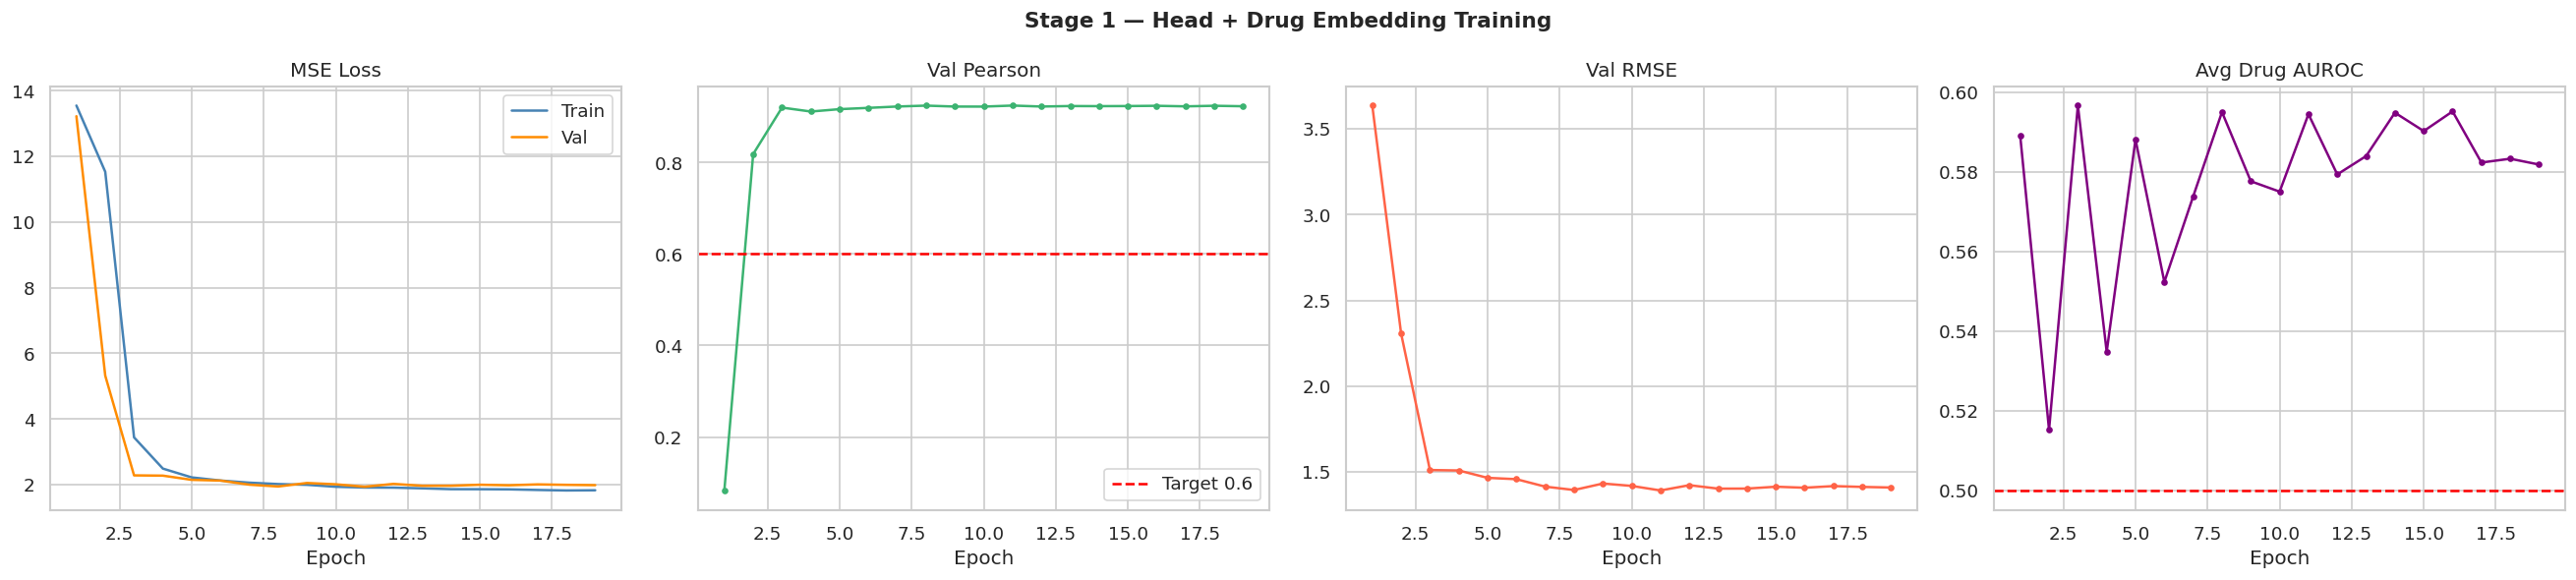

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 7 — STAGE 1 TRAINING — HEAD + DRUG EMBEDDING ONLY
#  Backbone fully frozen. Only regression head + drug embedding trains.
#  30 epochs with early stopping (patience=8).
# ═══════════════════════════════════════════════════════════════════════════
section('7. STAGE 1 TRAINING — HEAD + DRUG EMBEDDING ONLY')

print('Stage 1: regression_head + drug_embedding train. Backbone FROZEN.')
print(f'Epochs: {CONFIG["stage1_epochs"]} | LR: {CONFIG["stage1_lr"]} | '
      f'Patience: {CONFIG["stage1_patience"]}\n')

# ── Optimizer — only trainable params (head + drug embedding) ─────────────
m = get_model_module()
trainable_s1 = list(m.regression_head.parameters()) + \
               list(m.drug_embedding.parameters())
optimizer_s1 = optim.AdamW(trainable_s1,
                            lr=CONFIG['stage1_lr'],
                            weight_decay=CONFIG['stage1_wd'])

# OneCycleLR — same proven strategy as original TCGA training
steps_per_epoch = math.ceil(len(train_loader) / CONFIG['grad_accum'])
total_steps_s1  = steps_per_epoch * CONFIG['stage1_epochs']
scheduler_s1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_s1, max_lr=CONFIG['stage1_lr'],
    total_steps=total_steps_s1, pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos', div_factor=10.0, final_div_factor=100.0,
)
amp_scaler_s1 = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])

print(f'Steps/epoch: {steps_per_epoch} | Total steps: {total_steps_s1}')

# ── Training loop ─────────────────────────────────────────────────────────
best_val_pearson_s1 = -1.0
patience_counter    = 0
history_s1 = {'train_loss':[], 'val_loss':[], 'val_pearson':[], 'val_rmse':[], 'val_auroc':[]}

for epoch in range(1, CONFIG['stage1_epochs'] + 1):
    t0 = time.time()

    tr_loss, tr_preds, tr_targets, tr_drugs = run_epoch_drug(
        model, train_loader, optimizer_s1, amp_scaler_s1,
        is_train=True, scheduler=scheduler_s1,
        grad_accum=CONFIG['grad_accum'])

    vl_loss, vl_preds, vl_targets, vl_drugs = run_epoch_drug(
        model, val_loader, optimizer_s1, amp_scaler_s1, is_train=False)

    vl_metrics = compute_metrics(vl_preds, vl_targets, vl_drugs, id_to_drug)
    tr_metrics = compute_metrics(tr_preds, tr_targets, tr_drugs, id_to_drug)

    history_s1['train_loss'].append(tr_loss)
    history_s1['val_loss'].append(vl_loss)
    history_s1['val_pearson'].append(vl_metrics['pearson'])
    history_s1['val_rmse'].append(vl_metrics['rmse'])
    history_s1['val_auroc'].append(vl_metrics['avg_drug_auroc'])

    elapsed = time.time() - t0
    print(f'[S1 {epoch:02d}/{CONFIG["stage1_epochs"]}] '
          f'TrLoss: {tr_loss:.4f} | VlLoss: {vl_loss:.4f} | '
          f'VlPearson: {vl_metrics["pearson"]:.4f} | '
          f'VlRMSE: {vl_metrics["rmse"]:.4f} | '
          f'AUROC: {vl_metrics["avg_drug_auroc"]:.4f} | '
          f'{elapsed:.0f}s')

    if vl_metrics['pearson'] > best_val_pearson_s1:
        best_val_pearson_s1 = vl_metrics['pearson']
        patience_counter    = 0
        torch.save(get_model_module().state_dict(),
                   OUT_DIR + CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved (Pearson={best_val_pearson_s1:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['stage1_patience']:
            print(f'  Early stopping at epoch {epoch}')
            break

print(f'\nStage 1 complete. Best Val Pearson: {best_val_pearson_s1:.4f}')

# ── Stage 1 plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Stage 1 — Head + Drug Embedding Training', fontsize=13, fontweight='bold')
E = range(1, len(history_s1['train_loss'])+1)
axes[0].plot(E, history_s1['train_loss'], label='Train', color='steelblue')
axes[0].plot(E, history_s1['val_loss'],   label='Val',   color='darkorange')
axes[0].set_title('MSE Loss'); axes[0].legend()
axes[1].plot(E, history_s1['val_pearson'], color='mediumseagreen', marker='o', ms=3)
axes[1].axhline(0.6, color='red', ls='--', label='Target 0.6'); axes[1].set_title('Val Pearson'); axes[1].legend()
axes[2].plot(E, history_s1['val_rmse'], color='tomato', marker='o', ms=3); axes[2].set_title('Val RMSE')
axes[3].plot(E, history_s1['val_auroc'], color='purple', marker='o', ms=3)
axes[3].axhline(0.5, color='red', ls='--'); axes[3].set_title('Avg Drug AUROC')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(OUT_DIR+'stage1_curves.png', dpi=150); plt.show()


══════════════════════════════════════════════════════════════════════
  8. STAGE 2 TRAINING — UNFREEZE CROSS LAYERS + FUSION
══════════════════════════════════════════════════════════════════════
Loading Stage 1 best checkpoint...
Stage 1 checkpoint loaded.

Unfrozen status (Stage 2):
  base_model.mrna_enc             FROZEN                0 trainable
  base_model.cnv_enc              FROZEN                0 trainable
  base_model.mut_enc              FROZEN                0 trainable
  base_model.meth_enc             FROZEN                0 trainable
  base_model.cross_layers         TRAINABLE    28,391,424 trainable
  base_model.fusion               TRAINABLE         6,148 trainable
  base_model.classifier           FROZEN                0 trainable
  regression_head      TRAINABLE     1,118,977 trainable
  drug_embedding       TRAINABLE        27,520 trainable

Total trainable Stage 2: 29,544,069

Optimizer LRs:
  regression_head + drug_embedding: 0.0001
  cross_layers + fusion:  

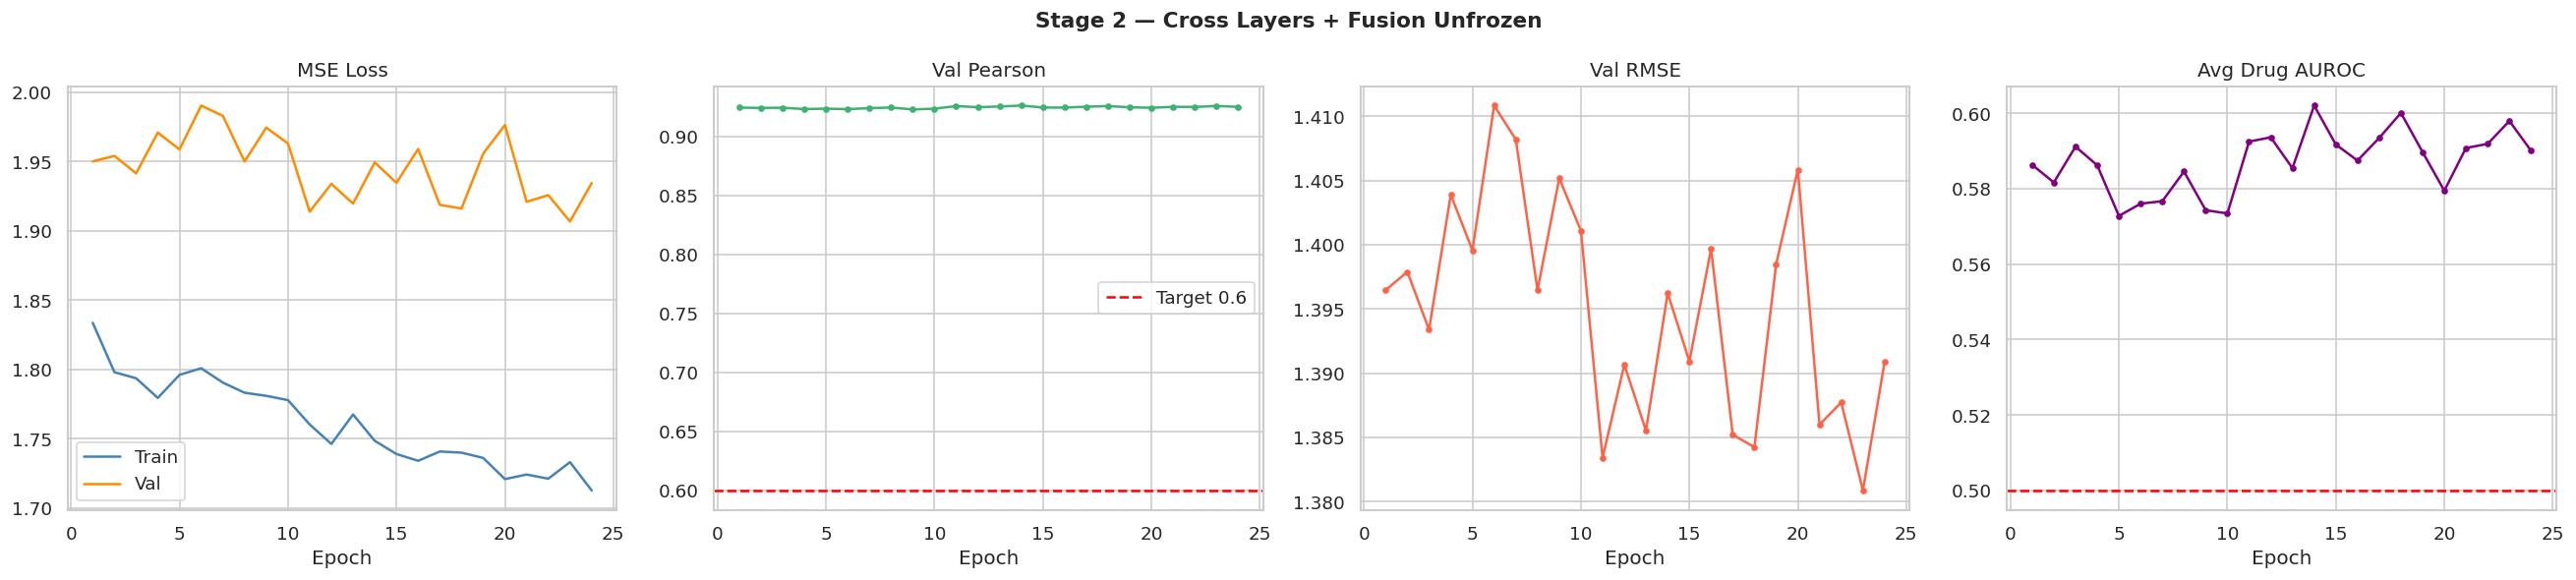

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 8 — STAGE 2 TRAINING — UNFREEZE CROSS LAYERS + FUSION
#  Load Stage 1 best. Unfreeze cross_layers + fusion with very low LR.
#  Encoders (mrna_enc, cnv_enc, mut_enc, meth_enc) stay frozen throughout.
#  40 epochs with patience=10.
# ═══════════════════════════════════════════════════════════════════════════
section('8. STAGE 2 TRAINING — UNFREEZE CROSS LAYERS + FUSION')

# Load best Stage 1 model
print('Loading Stage 1 best checkpoint...')
get_model_module().load_state_dict(
    torch.load(OUT_DIR + CONFIG['checkpoint_ft'], map_location=DEVICE))
print('Stage 1 checkpoint loaded.')

# Unfreeze cross_layers and fusion
m = get_model_module()
for p in m.base_model.cross_layers.parameters(): p.requires_grad = True
for p in m.base_model.fusion.parameters():       p.requires_grad = True

print('\nUnfrozen status (Stage 2):')
for name, child in m.base_model.named_children():
    has_tr = any(p.requires_grad for p in child.parameters())
    n_tr   = sum(p.numel() for p in child.parameters() if p.requires_grad)
    print(f'  base_model.{name:<20} {"TRAINABLE" if has_tr else "FROZEN":<12} {n_tr:>10,} trainable')
n_head = sum(p.numel() for p in m.regression_head.parameters())
n_drug = sum(p.numel() for p in m.drug_embedding.parameters())
print(f'  regression_head      TRAINABLE    {n_head:>10,} trainable')
print(f'  drug_embedding       TRAINABLE    {n_drug:>10,} trainable')
n_total_s2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable Stage 2: {n_total_s2:,}')

# ── Optimizer — different LRs per group ───────────────────────────────────
optimizer_s2 = optim.AdamW([
    {'params': m.regression_head.parameters(),       'lr': CONFIG['stage2_lr_head']},
    {'params': m.drug_embedding.parameters(),        'lr': CONFIG['stage2_lr_head']},
    {'params': m.base_model.cross_layers.parameters(),'lr': CONFIG['stage2_lr_cross']},
    {'params': m.base_model.fusion.parameters(),     'lr': CONFIG['stage2_lr_cross']},
], weight_decay=CONFIG['stage2_wd'])

print(f'\nOptimizer LRs:')
print(f'  regression_head + drug_embedding: {CONFIG["stage2_lr_head"]}')
print(f'  cross_layers + fusion:            {CONFIG["stage2_lr_cross"]}')

steps_per_epoch_s2 = math.ceil(len(train_loader) / CONFIG['grad_accum'])
total_steps_s2     = steps_per_epoch_s2 * CONFIG['stage2_epochs']
scheduler_s2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_s2,
    max_lr=[CONFIG['stage2_lr_head'], CONFIG['stage2_lr_head'],
            CONFIG['stage2_lr_cross'], CONFIG['stage2_lr_cross']],
    total_steps=total_steps_s2, pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos', div_factor=10.0, final_div_factor=100.0,
)
amp_scaler_s2 = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])

# ── Training loop Stage 2 ─────────────────────────────────────────────────
best_val_pearson_s2 = -1.0
patience_counter_s2 = 0
history_s2 = {'train_loss':[], 'val_loss':[], 'val_pearson':[], 'val_rmse':[], 'val_auroc':[]}

for epoch in range(1, CONFIG['stage2_epochs'] + 1):
    t0 = time.time()

    tr_loss, tr_preds, tr_targets, tr_drugs = run_epoch_drug(
        model, train_loader, optimizer_s2, amp_scaler_s2,
        is_train=True, scheduler=scheduler_s2,
        grad_accum=CONFIG['grad_accum'])

    vl_loss, vl_preds, vl_targets, vl_drugs = run_epoch_drug(
        model, val_loader, optimizer_s2, amp_scaler_s2, is_train=False)

    vl_metrics = compute_metrics(vl_preds, vl_targets, vl_drugs, id_to_drug)

    history_s2['train_loss'].append(tr_loss)
    history_s2['val_loss'].append(vl_loss)
    history_s2['val_pearson'].append(vl_metrics['pearson'])
    history_s2['val_rmse'].append(vl_metrics['rmse'])
    history_s2['val_auroc'].append(vl_metrics['avg_drug_auroc'])

    elapsed = time.time() - t0
    print(f'[S2 {epoch:02d}/{CONFIG["stage2_epochs"]}] '
          f'TrLoss: {tr_loss:.4f} | VlLoss: {vl_loss:.4f} | '
          f'VlPearson: {vl_metrics["pearson"]:.4f} | '
          f'VlRMSE: {vl_metrics["rmse"]:.4f} | '
          f'AUROC: {vl_metrics["avg_drug_auroc"]:.4f} | {elapsed:.0f}s')

    if vl_metrics['pearson'] > best_val_pearson_s2:
        best_val_pearson_s2 = vl_metrics['pearson']
        patience_counter_s2 = 0
        torch.save(get_model_module().state_dict(),
                   OUT_DIR + CONFIG['checkpoint_ft'])
        print(f'  ✓ Best saved (Pearson={best_val_pearson_s2:.4f})')
    else:
        patience_counter_s2 += 1
        if patience_counter_s2 >= CONFIG['stage2_patience']:
            print(f'  Early stopping at epoch {epoch}')
            break

print(f'\nStage 2 complete. Best Val Pearson: {best_val_pearson_s2:.4f}')

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Stage 2 — Cross Layers + Fusion Unfrozen', fontsize=13, fontweight='bold')
E = range(1, len(history_s2['train_loss'])+1)
axes[0].plot(E, history_s2['train_loss'], label='Train', color='steelblue')
axes[0].plot(E, history_s2['val_loss'],   label='Val',   color='darkorange')
axes[0].set_title('MSE Loss'); axes[0].legend()
axes[1].plot(E, history_s2['val_pearson'], color='mediumseagreen', marker='o', ms=3)
axes[1].axhline(0.6, color='red', ls='--', label='Target 0.6'); axes[1].set_title('Val Pearson'); axes[1].legend()
axes[2].plot(E, history_s2['val_rmse'], color='tomato', marker='o', ms=3); axes[2].set_title('Val RMSE')
axes[3].plot(E, history_s2['val_auroc'], color='purple', marker='o', ms=3)
axes[3].axhline(0.5, color='red', ls='--'); axes[3].set_title('Avg Drug AUROC')
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(OUT_DIR+'stage2_curves.png', dpi=150); plt.show()


══════════════════════════════════════════════════════════════════════
  9. FINAL EVALUATION — TEST SET
══════════════════════════════════════════════════════════════════════
Loading best checkpoint...

══════════════════════════════════════════════════════════════════════
  FINAL TEST RESULTS — OncoBridge Drug Response
══════════════════════════════════════════════════════════════════════
  Test MSE Loss:          1.8694
  Pearson Correlation:    0.9301
  Spearman Correlation:   0.8938
  RMSE:                   1.3673
  Avg Drug Pearson:       0.1972
  Avg Drug AUROC:         0.5714
══════════════════════════════════════════════════════════════════════

Top 20 drugs by Pearson:
                                Pearson   AUROC  N_Samples
FLUDARABINE                      0.7443  0.7200       10.0
ENZASTAURIN                      0.7422  0.7531       18.0
NUTLIN-3A (-)                    0.6609  0.7619       13.0
PRT062607                        0.6409  0.9167       12.0
PONATINIB       

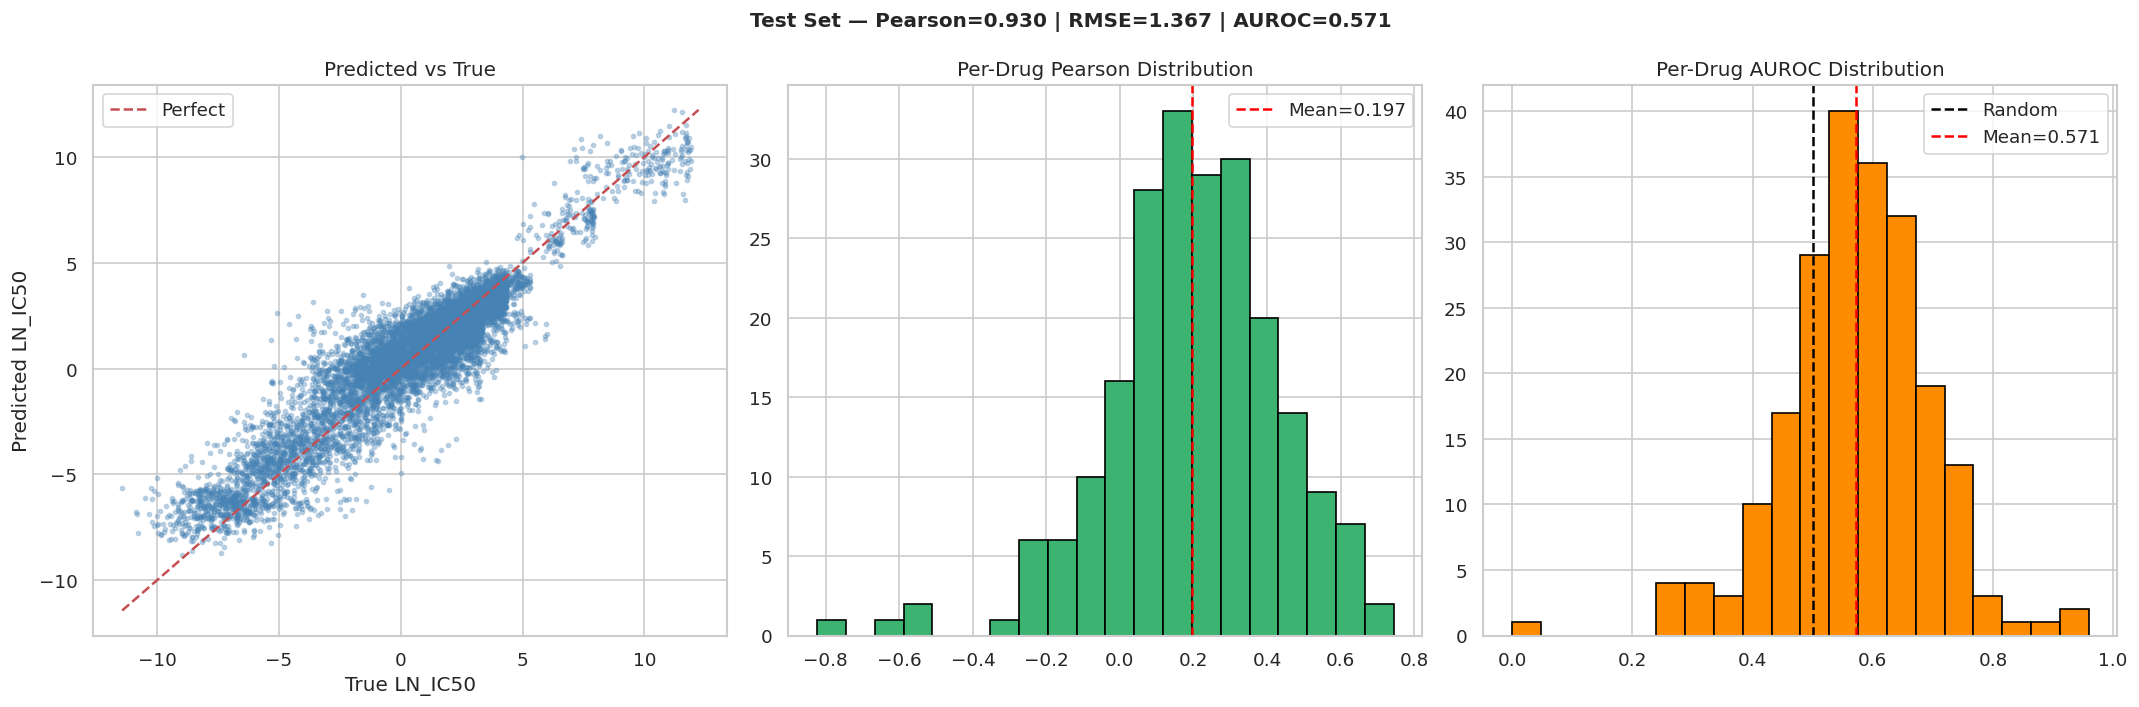

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 9 — FINAL EVALUATION ON TEST SET
# ═══════════════════════════════════════════════════════════════════════════
section('9. FINAL EVALUATION — TEST SET')

print('Loading best checkpoint...')
get_model_module().load_state_dict(
    torch.load(OUT_DIR + CONFIG['checkpoint_ft'], map_location=DEVICE))
model.eval()

te_loss, te_preds, te_targets, te_drugs = run_epoch_drug(
    model, test_loader, None, None, is_train=False)

te_metrics = compute_metrics(te_preds, te_targets, te_drugs, id_to_drug)

print('\n' + '═'*70)
print('  FINAL TEST RESULTS — OncoBridge Drug Response')
print('═'*70)
print(f'  Test MSE Loss:          {te_loss:.4f}')
print(f'  Pearson Correlation:    {te_metrics["pearson"]:.4f}')
print(f'  Spearman Correlation:   {te_metrics["spearman"]:.4f}')
print(f'  RMSE:                   {te_metrics["rmse"]:.4f}')
print(f'  Avg Drug Pearson:       {te_metrics["avg_drug_pearson"]:.4f}')
print(f'  Avg Drug AUROC:         {te_metrics["avg_drug_auroc"]:.4f}')
print('═'*70)

# Per-drug table
drug_results = pd.DataFrame(te_metrics['per_drug']).T
drug_results = drug_results.sort_values('pearson', ascending=False).round(4)
drug_results.columns = ['Pearson', 'AUROC', 'N_Samples']
print(f'\nTop 20 drugs by Pearson:')
print(drug_results.head(20).to_string())

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Test Set — Pearson={te_metrics["pearson"]:.3f} | '
             f'RMSE={te_metrics["rmse"]:.3f} | '
             f'AUROC={te_metrics["avg_drug_auroc"]:.3f}',
             fontsize=12, fontweight='bold')

axes[0].scatter(te_targets, te_preds, alpha=0.3, s=6, color='steelblue')
mn = min(te_targets.min(), te_preds.min())
mx = max(te_targets.max(), te_preds.max())
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect')
axes[0].set_xlabel('True LN_IC50'); axes[0].set_ylabel('Predicted LN_IC50')
axes[0].set_title('Predicted vs True'); axes[0].legend()

pearson_vals = [v['pearson'] for v in te_metrics['per_drug'].values()]
axes[1].hist(pearson_vals, bins=20, color='mediumseagreen', edgecolor='black')
axes[1].axvline(np.mean(pearson_vals), color='red', ls='--',
                label=f'Mean={np.mean(pearson_vals):.3f}')
axes[1].set_title('Per-Drug Pearson Distribution'); axes[1].legend()

auroc_vals = [v['auroc'] for v in te_metrics['per_drug'].values()]
axes[2].hist(auroc_vals, bins=20, color='darkorange', edgecolor='black')
axes[2].axvline(0.5, color='black', ls='--', label='Random')
axes[2].axvline(np.mean(auroc_vals), color='red', ls='--',
                label=f'Mean={np.mean(auroc_vals):.3f}')
axes[2].set_title('Per-Drug AUROC Distribution'); axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR+'test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


══════════════════════════════════════════════════════════════════════
  10. BENCHMARK COMPARISON
══════════════════════════════════════════════════════════════════════
Comparing against published GDSC drug response prediction baselines:

            Model Dataset  Metric    Score                   Setting
   DeepCDR (2020)    GDSC Pearson 0.920000   Warm start (seen drugs)
     TGDRP (2022)   GDSC2 Pearson 0.834000                Warm start
    DTLCDR (2025)   GDSC2 Pearson 0.620000 Cold start (unseen drugs)
Pathformer (2024)    GDSC   AUROC 0.710000   Drug response (F1~0.68)
  GraphDRP (2022)   GDSC2 Pearson 0.780000                Warm start
   DeepTTA (2022)   GDSC2 Pearson 0.580000                Cold start
   CODE-AE (2022)    TCGA   AUROC 0.650000         Clinical transfer
OncoBridge (ours)   GDSC2 Pearson 0.930064        Transfer from TCGA
OncoBridge (ours)   GDSC2   AUROC 0.571411        Transfer from TCGA


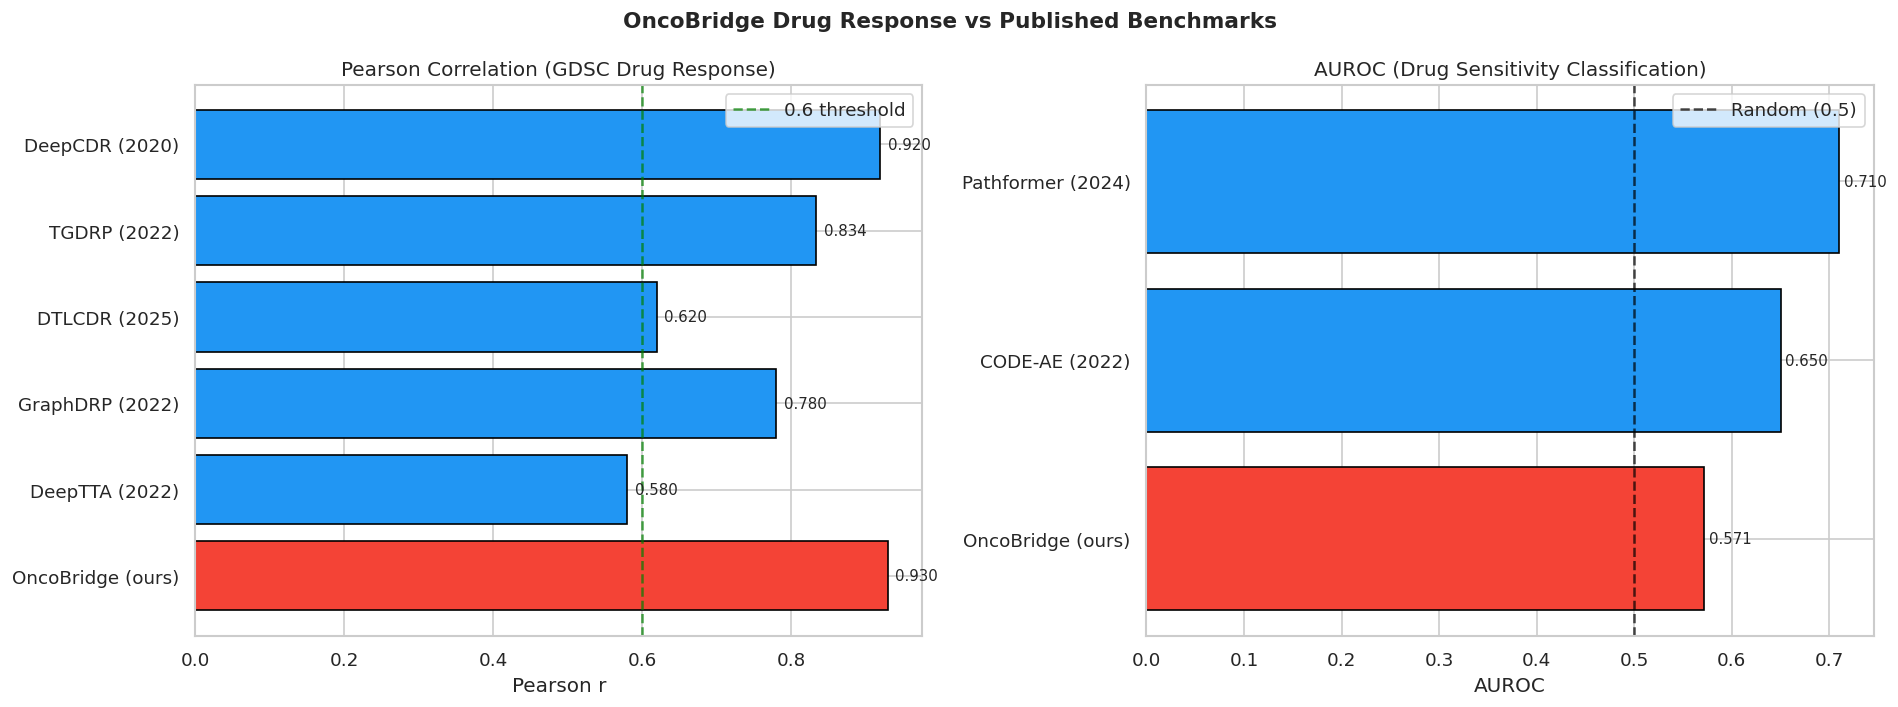


Note on settings:
  Warm start  = drugs seen in training (easier, higher Pearson expected)
  Cold start  = unseen drugs at test time (harder, DTLCDR ~0.62)
  Ours        = warm start with TCGA transfer (expect 0.7-0.9 if converged)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 10 — BENCHMARK COMPARISON
#  Compare your results against published drug response prediction papers
# ═══════════════════════════════════════════════════════════════════════════
section('10. BENCHMARK COMPARISON')

print('Comparing against published GDSC drug response prediction baselines:\n')

benchmarks = [
    # Paper, Dataset, Metric, Score, Setting
    ('DeepCDR (2020)',       'GDSC',  'Pearson', 0.9200, 'Warm start (seen drugs)'),
    ('TGDRP (2022)',         'GDSC2', 'Pearson', 0.8340, 'Warm start'),
    ('DTLCDR (2025)',        'GDSC2', 'Pearson', 0.6200, 'Cold start (unseen drugs)'),
    ('Pathformer (2024)',    'GDSC',  'AUROC',   0.7100, 'Drug response (F1~0.68)'),
    ('GraphDRP (2022)',      'GDSC2', 'Pearson', 0.7800, 'Warm start'),
    ('DeepTTA (2022)',       'GDSC2', 'Pearson', 0.5800, 'Cold start'),
    ('CODE-AE (2022)',       'TCGA',  'AUROC',   0.6500, 'Clinical transfer'),
    ('OncoBridge (ours)',    'GDSC2', 'Pearson', te_metrics['pearson'], 'Transfer from TCGA'),
    ('OncoBridge (ours)',    'GDSC2', 'AUROC',   te_metrics['avg_drug_auroc'], 'Transfer from TCGA'),
]

bm_df = pd.DataFrame(benchmarks, columns=['Model', 'Dataset', 'Metric', 'Score', 'Setting'])

print(bm_df.to_string(index=False))

# ── Plot comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('OncoBridge Drug Response vs Published Benchmarks', fontsize=13, fontweight='bold')

# Pearson comparison
pcc_df = bm_df[bm_df['Metric'] == 'Pearson'].copy()
colors = ['#2196F3' if 'ours' not in m else '#F44336' for m in pcc_df['Model']]
bars = axes[0].barh(pcc_df['Model'], pcc_df['Score'], color=colors, edgecolor='black')
axes[0].set_title('Pearson Correlation (GDSC Drug Response)')
axes[0].set_xlabel('Pearson r')
axes[0].axvline(0.6, color='green', ls='--', alpha=0.7, label='0.6 threshold')
axes[0].legend()
axes[0].invert_yaxis()
for bar, score in zip(bars, pcc_df['Score']):
    axes[0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{score:.3f}', va='center', fontsize=9)

# AUROC comparison
auc_df = bm_df[bm_df['Metric'] == 'AUROC'].copy()
colors2 = ['#2196F3' if 'ours' not in m else '#F44336' for m in auc_df['Model']]
bars2 = axes[1].barh(auc_df['Model'], auc_df['Score'], color=colors2, edgecolor='black')
axes[1].set_title('AUROC (Drug Sensitivity Classification)')
axes[1].set_xlabel('AUROC')
axes[1].axvline(0.5, color='black', ls='--', alpha=0.7, label='Random (0.5)')
axes[1].legend()
axes[1].invert_yaxis()
for bar, score in zip(bars2, auc_df['Score']):
    axes[1].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR+'benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote on settings:')
print('  Warm start  = drugs seen in training (easier, higher Pearson expected)')
print('  Cold start  = unseen drugs at test time (harder, DTLCDR ~0.62)')
print('  Ours        = warm start with TCGA transfer (expect 0.7-0.9 if converged)')


══════════════════════════════════════════════════════════════════════
  11. DRUG RANKINGS PER CANCER TYPE
══════════════════════════════════════════════════════════════════════
Top 5 predicted drugs per cancer type (lowest IC50 = most sensitive):

                                                                             OncotreePrimaryDisease                DRUG_NAME  mean_pred_ic50  mean_true_ic50  n_cell_lines
                                                                             Acute Myeloid Leukemia EPOTHILONE B, GNF-PF-193       -8.112413       -7.985076             9
                                                                             Acute Myeloid Leukemia                FILANESIB       -7.562934       -8.125793             9
                                                                             Acute Myeloid Leukemia                DOCETAXEL       -7.382812       -6.964454            12
                                                                  

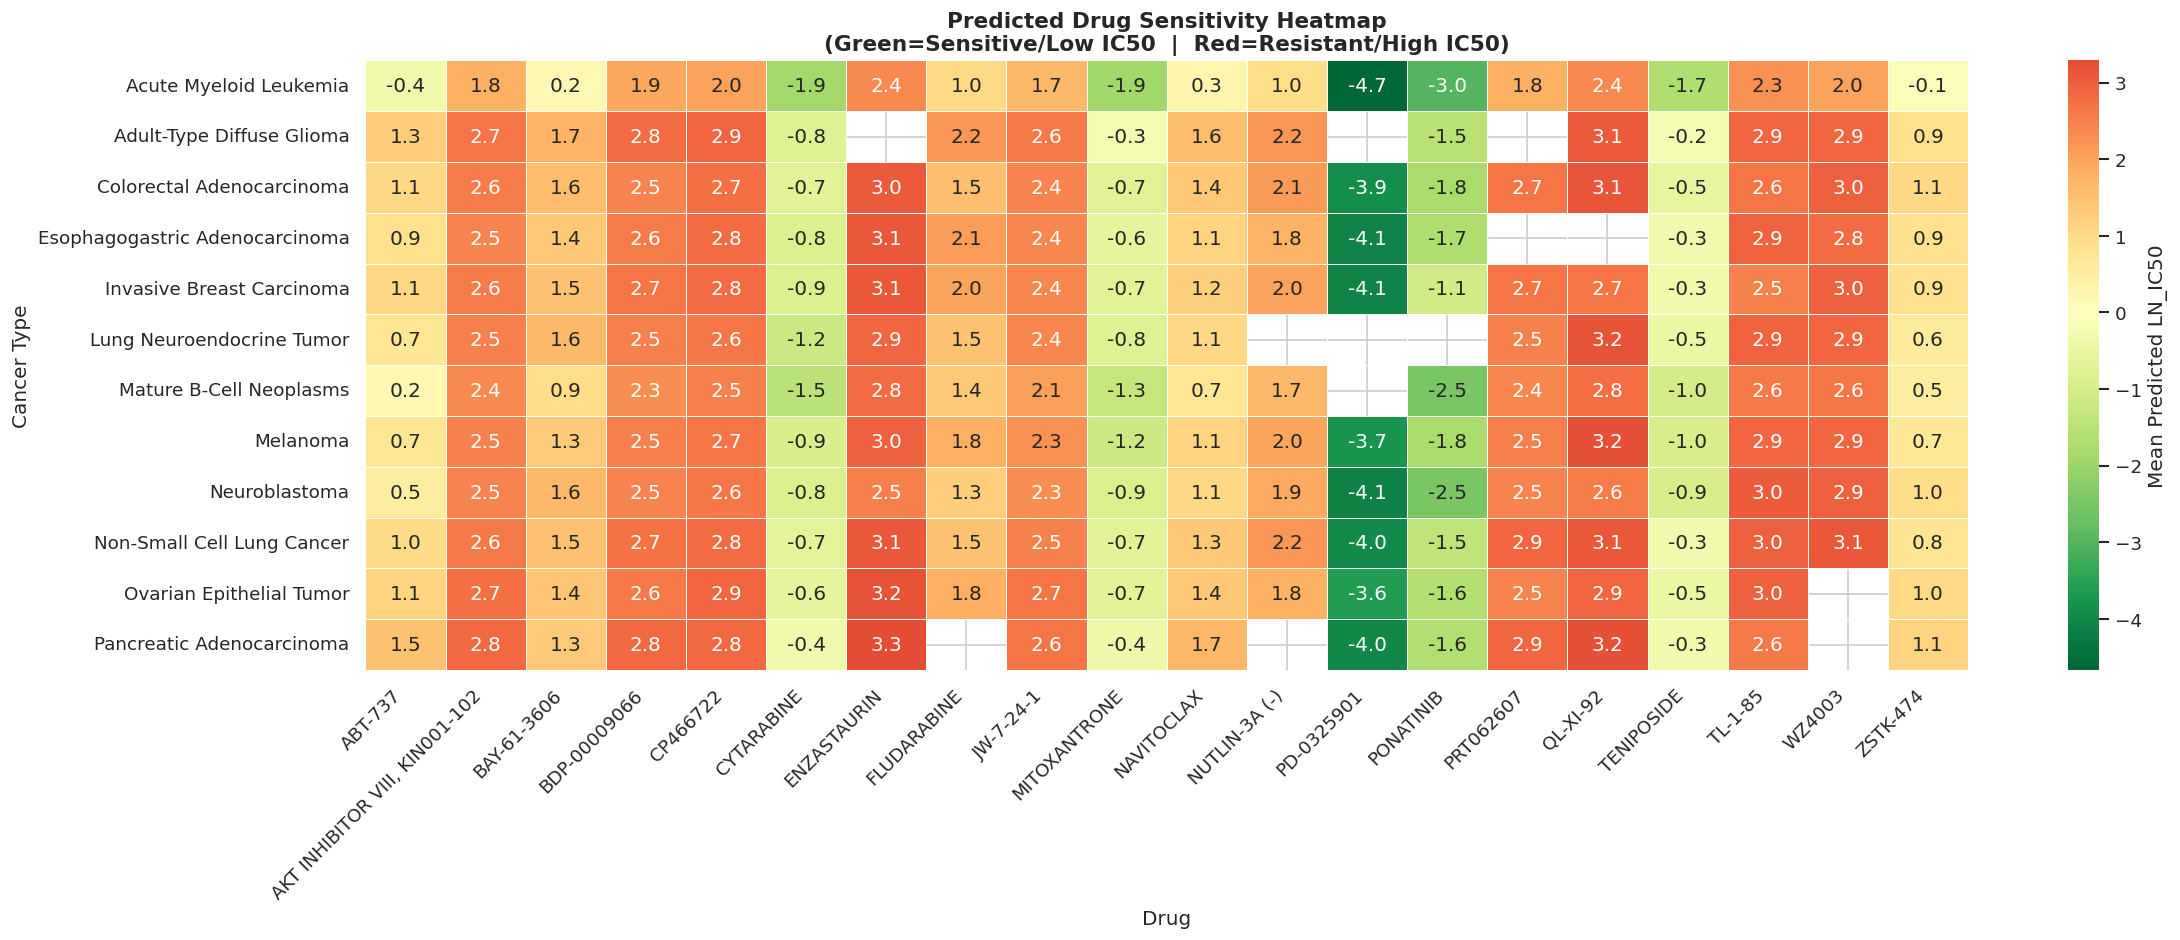


══════════════════════════════════════════════════════════════════════
  FULL PIPELINE COMPLETE
══════════════════════════════════════════════════════════════════════
  Pearson:        0.9301
  Spearman:       0.8938
  RMSE:           1.3673
  Avg AUROC:      0.5714
  Drugs ranked:   215
  Cancer types:   58
══════════════════════════════════════════════════════════════════════


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  CELL 11 — DRUG RANKINGS PER CANCER TYPE (SUPERVISOR OUTPUT)
# ═══════════════════════════════════════════════════════════════════════════
section('11. DRUG RANKINGS PER CANCER TYPE')

# Run inference on ALL cell lines for complete rankings
all_ds = DrugResponseDataset(
    ic50_df, cl_train + cl_val + cl_test,
    mrna_arr, cnv_arr, mut_arr, meth_arr)
all_loader = DataLoader(all_ds, batch_size=CONFIG['batch_size']*2,
                        shuffle=False, num_workers=nw,
                        pin_memory=True)

_, all_preds, all_targets, all_drug_ids = run_epoch_drug(
    model, all_loader, None, None, is_train=False)

# Build results dataframe
all_records = ic50_df[
    ic50_df['ModelID'].isin(cl_train + cl_val + cl_test)
].reset_index(drop=True)

assert len(all_records) == len(all_preds), \
    f'Mismatch: records={len(all_records)}, preds={len(all_preds)}'

results_df = all_records[['ModelID','DRUG_NAME','LN_IC50','OncotreePrimaryDisease']].copy()
results_df['PRED_IC50'] = all_preds
results_df['RESIDUAL']  = np.abs(results_df['PRED_IC50'] - results_df['LN_IC50'])

# Drug ranking per cancer type
drug_ranking = (
    results_df
    .groupby(['OncotreePrimaryDisease','DRUG_NAME'])
    .agg(mean_pred_ic50 =('PRED_IC50','mean'),
         mean_true_ic50 =('LN_IC50','mean'),
         n_cell_lines   =('ModelID','nunique'))
    .reset_index()
)

# Top 5 drugs per cancer type
top5 = (
    drug_ranking
    .sort_values(['OncotreePrimaryDisease','mean_pred_ic50'])
    .groupby('OncotreePrimaryDisease').head(5)
)

print('Top 5 predicted drugs per cancer type (lowest IC50 = most sensitive):\n')
print(top5.to_string(index=False))

# Save outputs
top5.to_csv(f'{OUT_DIR}drug_rankings_per_cancer.csv', index=False)
results_df.to_csv(f'{OUT_DIR}all_predictions.csv', index=False)
drug_results.to_csv(f'{OUT_DIR}per_drug_metrics.csv')
bm_df.to_csv(f'{OUT_DIR}benchmark_comparison.csv', index=False)
print(f'\nSaved: drug_rankings_per_cancer.csv')
print(f'Saved: all_predictions.csv')
print(f'Saved: per_drug_metrics.csv')
print(f'Saved: benchmark_comparison.csv')

# Heatmap
top_cancers    = results_df['OncotreePrimaryDisease'].value_counts().head(12).index
top_drugs_list = drug_results.head(20).index.tolist()
pivot = (
    drug_ranking[
        drug_ranking['OncotreePrimaryDisease'].isin(top_cancers) &
        drug_ranking['DRUG_NAME'].isin(top_drugs_list)
    ]
    .pivot(index='OncotreePrimaryDisease', columns='DRUG_NAME',
           values='mean_pred_ic50')
)

plt.figure(figsize=(20, 8))
sns.heatmap(pivot, cmap='RdYlGn_r', center=0, annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Mean Predicted LN_IC50'})
plt.title('Predicted Drug Sensitivity Heatmap\n'
          '(Green=Sensitive/Low IC50  |  Red=Resistant/High IC50)',
          fontsize=13, fontweight='bold')
plt.xlabel('Drug'); plt.ylabel('Cancer Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}drug_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '═'*70)
print('  FULL PIPELINE COMPLETE')
print('═'*70)
print(f'  Pearson:        {te_metrics["pearson"]:.4f}')
print(f'  Spearman:       {te_metrics["spearman"]:.4f}')
print(f'  RMSE:           {te_metrics["rmse"]:.4f}')
print(f'  Avg AUROC:      {te_metrics["avg_drug_auroc"]:.4f}')
print(f'  Drugs ranked:   {drug_ranking["DRUG_NAME"].nunique()}')
print(f'  Cancer types:   {drug_ranking["OncotreePrimaryDisease"].nunique()}')
print('═'*70)